In [27]:
import cme.decision_models.confidence_accumulation as ca
import cme.decision_models.quantum_discrete as qd
import cme.decision_models.diffusion_discrete as dd

import jax.numpy as npx
import jax.scipy as scx
import pandas as pd
import seaborn as sns
import numpy as np
import seaborn.objects as so
import matplotlib.pyplot as plt
sns.set_context("paper", font_scale=2.5)

In [28]:
n_states, start_width, delta, measurement_prob,  I, J, steps = 11, 5, 1, 0.8, 1, 1, 0.1
m_Mc, m_Mw, m_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Markov")
q_Mc, q_Mw, q_Mn = ca._get_measurement_matrix(n_states, 1, prob=measurement_prob, model_type = "Quantum")


In [29]:
m_mu, m_sigma, T = npx.asarray([[1]]), npx.asarray([[2]]), 100
q_mu, q_sigma, T = npx.asarray([[0.58]]), npx.asarray([[1]]), 100

intensity_matrix_markov = dd._buildK(n_states, m_mu, m_sigma)
intensity_matrix_quantum = qd._buildH(n_states, q_mu, q_sigma)


In [30]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
           0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
           0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
           0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,
           0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ,  0. ,
           0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ,
           0. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ,
           0. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ,
           0. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  0.5,
           0. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ,
           2. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  1.5,
          -2. ]]]], dtype=float64)

In [31]:
intensity_matrix_quantum

Array([[[[0.+2.9j , 0.-1.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  ,
          0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  ],
         [0.-1.j  , 0.+2.32j, 0.-1.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  ,
          0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  ],
         [0.-0.j  , 0.-1.j  , 0.+1.74j, 0.-1.j  , 0.-0.j  , 0.-0.j  ,
          0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  ],
         [0.-0.j  , 0.-0.j  , 0.-1.j  , 0.+1.16j, 0.-1.j  , 0.-0.j  ,
          0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  ],
         [0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-1.j  , 0.+0.58j, 0.-1.j  ,
          0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  ],
         [0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-1.j  , 0.-0.j  ,
          0.-1.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  ],
         [0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-1.j  ,
          0.-0.58j, 0.-1.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  ],
         [0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  , 0.-0.j  ,
          0.-

In [32]:
phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type="Uniform")
phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type="Upper")
phi_0_markov, phi_0_quantum

(Array([[[[0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909],
          [0.09090909]]]], dtype=float64),
 Array([[[[0.       ],
          [0.       ],
          [0.       ],
          [0.       ],
          [0.       ],
          [0.       ],
          [0.4472136],
          [0.4472136],
          [0.4472136],
          [0.4472136],
          [0.4472136]]]], dtype=float64))

In [33]:
ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[0.5]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

Array([[[[0.04796291],
         [0.08750089],
         [0.09139445],
         [0.09122732],
         [0.09098927],
         [0.090924  ],
         [0.09093085],
         [0.09124439],
         [0.09530909],
         [0.1329518 ],
         [0.08956502]]]], dtype=float64)

In [34]:
phi_0_quantum = npx.array([[[[0.06871463],
         [0.07356508],
         [0.08124495],
         [0.10388036],
         [0.12732417],
         [0.11843169],
         [0.10549717],
         [0.09700889],
         [0.08124495],
         [0.06911884],
         [0.07396928]]]])
phi_0_quantum.shape

(1, 1, 11, 1)

In [35]:
df_markov = pd.DataFrame()
df_quantum = pd.DataFrame()
df_quantum_r = pd.DataFrame()
df_quantum_c = pd.DataFrame()
for prior_type in ["Upper", "Uniform", "Lower"]:
    phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
    #phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)

    phi_markov_arr = []
    phi_quantum_arr = []
    phi_quantum_arr_r = []
    phi_quantum_arr_c = []

    phi_markov_arr.append(np.asarray(phi_0_markov.squeeze()))
    phi_quantum_arr.append(np.abs(phi_0_quantum.squeeze())**2)

    #phi_quantum_arr_r.append(np.real(phi_0_quantum.squeeze()))
    #phi_quantum_arr_c.append(np.imag(phi_0_quantum.squeeze()))
    #df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    #df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])

    for t in np.arange(1,5/0.1,0.1):
        phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_markov_arr.append(np.asarray(phi_markov.squeeze()))
    for t in np.arange(1,5/0.1,0.1):
        phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")
        phi_quantum_arr.append(np.abs(phi_quantum.squeeze())**2)
        phi_quantum_arr_r.append(np.real(phi_quantum.squeeze()))
        phi_quantum_arr_c.append(np.imag(phi_quantum.squeeze()))
    
    df_markov = pd.concat([df_markov, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type)])
    df_quantum = pd.concat([df_quantum, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type)])
    df_quantum_r = pd.concat([df_quantum_r, pd.DataFrame(phi_quantum_arr_r).T.assign(prior=prior_type)])
    df_quantum_c = pd.concat([df_quantum_c, pd.DataFrame(phi_quantum_arr_c).T.assign(prior=prior_type)])
        

In [36]:
df_quantum_3d = df_quantum_r.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="real").reset_index(names="states").merge(
df_quantum_c.melt(id_vars = "prior", ignore_index=False, var_name="time", value_name="imag").reset_index(names="states"),
on=["states", "time", "prior"]
).assign(states = lambda df: df.states - n_states//2 )
df_quantum_3d = df_quantum_3d.assign(time=lambda df: df.time * 0.1)
df_quantum_3d

,states,prior,time,real,imag
0,-5,Upper,0.0,-0.00694811232771704,0.02662247248698873
1,-4,Upper,0.0,0.04654549995781582,0.04471741886123358
2,-3,Upper,0.0,0.08648719870922712,-0.017674561641634296
3,-2,Upper,0.0,0.0739935337633833,-0.06986154378666552
4,-1,Upper,0.0,0.039037804917999415,-0.10016068207912633
...,...,...,...,...,...
16165,1,Lower,48.9,-0.02038065886561901,-0.10990081460744033
16166,2,Lower,48.9,0.10741869802794815,-0.12739480547771778
16167,3,Lower,48.9,0.08038971251538245,0.025780500203522003
16168,4,Lower,48.9,0.12568487822789035,0.092766298908709


In [37]:
import plotly.io as pio
pio.renderers


Renderers configuration
-----------------------
    Default renderer: 'browser'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

In [59]:
import plotly.express as px
pio.renderers.default = "vscode" #"browser" #
fig = px.line_3d(df_quantum_3d.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ).query("time < 10.24").assign(time = lambda df: df.time * 0.1) \
                 .query("prior == 'Uniform' and time < 30").rename(columns={"time":"Time", "real":"Real", "imag":"Imaginary"}), 
                 x="Time", y="Real", z="Imaginary", color="state_labels", title = 'Probability "Amplitude" Trajectory <br> (Participant #1)',
labels = {"real":"Real", "imag": "Imaginary"}
)
fig.update_layout(legend_title = "States", 
    scene=dict(aspectratio = dict( x=2.5, y=1, z=1 ),
    aspectmode = 'manual'),
    autosize=True
    )
fig.update_traces(line=dict(
        width=10
    ))
fig.update_layout(
    legend_title_font=dict(size=50, color="black"),
    title_font=dict(size=60, color="black"),
    font=dict(
        
        size=20,  # Set the font size here
    ))
fig.update_scenes(
    xaxis=dict(title='Observed time (in secs)', tickfont=dict(size=15), titlefont=dict(size=45)),
    yaxis=dict(title='Real', tickfont=dict(size=15), titlefont=dict(size=45)),
    zaxis=dict(title='Imaginary', tickfont=dict(size=15), titlefont=dict(size=45)),
)
fig.layout.template = "seaborn"
fig.show()
import plotly.io as pio
#pio.write_image(fig, 'image.png',format="png",scale=1, width=1080, height=1080)

In [39]:
df_quantum_3d.query("states == 6 and prior == 'Upper' and time > 10 and time < 100")

,states,prior,time,real,imag


In [40]:
intensity_matrix_markov

Array([[[[-2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
           0. ],
         [ 2. , -2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
           0. ],
         [ 0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
           0. ],
         [ 0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ,  0. ,  0. ,
           0. ],
         [ 0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ,  0. ,
           0. ],
         [ 0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ,  0. ,
           0. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ,  0. ,
           0. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  0.5,  0. ,
           0. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ,  0.5,
           0. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  1.5, -2. ,
           2. ],
         [ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  1.5,
          -2. ]]]], dtype=float64)

In [41]:
pd.DataFrame(scx.linalg.expm(intensity_matrix_markov*20).squeeze())

,0,1,2,3,4,5,6,7,8,9,10
0,0.000056,0.000049,0.000039,0.000031,0.000024,0.000021,0.000019,0.000017,0.000017,0.000017,0.000017
1,0.000196,0.000173,0.000141,0.000113,0.000093,0.000080,0.000073,0.000069,0.000068,0.000067,0.000067
2,0.000469,0.000422,0.000355,0.000296,0.000255,0.000229,0.000214,0.000207,0.000204,0.000202,0.000202
3,0.001100,0.001013,0.000889,0.000782,0.000706,0.000658,0.000630,0.000617,0.000610,0.000608,0.000608
4,0.002644,0.002501,0.002295,0.002117,0.001990,0.001910,0.001864,0.001841,0.001830,0.001826,0.001826
5,0.006704,0.006491,0.006185,0.005920,0.005730,0.005609,0.005540,0.005505,0.005489,0.005483,0.005482
6,0.018032,0.017758,0.017365,0.017023,0.016777,0.016621,0.016531,0.016484,0.016463,0.016456,0.016454
7,0.050921,0.050655,0.050271,0.049937,0.049696,0.049542,0.049453,0.049406,0.049386,0.049378,0.049377
8,0.148523,0.148461,0.148370,0.148289,0.148230,0.148191,0.148169,0.148157,0.148151,0.148149,0.148149
9,0.441079,0.441668,0.442513,0.443249,0.443776,0.444111,0.444304,0.444403,0.444448,0.444464,0.444466


In [42]:
df_markov_plot = df_markov.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*0.1).reset_index(names="states").assign(states = lambda df: df.states - n_states//2 )
df_quantum_plot = df_quantum.melt(id_vars = "prior", ignore_index=False, var_name="time").assign(time = lambda df:df.time*0.1).reset_index(names="states").assign(states = lambda df: df.states - n_states//2)
df_markov_plot = df_markov_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum_plot = df_quantum_plot.assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))

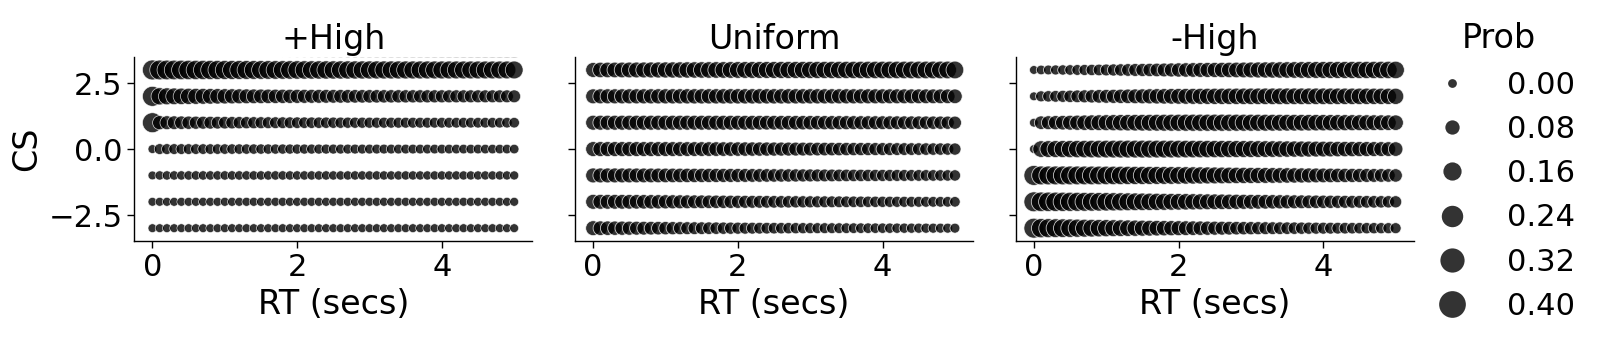

In [43]:
with sns.plotting_context(font_scale=2.5):
    f = sns.relplot(df_markov_plot
                    .query("time <= 5")
                    ,alpha=0.8,
    x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1.3, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()


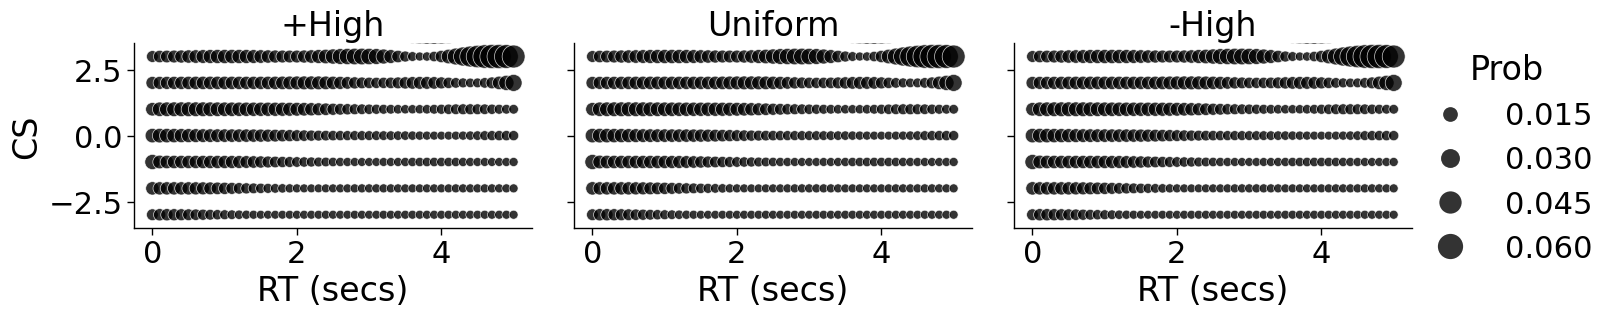

In [44]:
with sns.plotting_context(font_scale=2.5):
    f = sns.relplot(df_quantum_plot
                    .query("time <= 5")
                    ,alpha=0.8,
    x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1.3, height=3.7)
    f.set_titles("{col_name}")
    f.legend.set_title("Prob")
    f.set_xlabels("RT (secs)")
    f.set_ylabels("CS")
    f.set(ylim=(-3.5, 3.5))
#f.legend.set_bbox_to_anchor((0.9,0.5))
#f.legend.set_loc("lower right")
#plt.tight_layout()

In [45]:
import matplotlib as mpl
mpl.rcParams

RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'both',
   

In [46]:
mid = int(n_states+1)/2
states_ticks = np.arange(-(mid-1), mid)
states_labels = (states_ticks + (5 * np.sign(states_ticks))) * 10
states_labels

array([-100.,  -90.,  -80.,  -70.,  -60.,    0.,   60.,   70.,   80.,
         90.,  100.])

In [47]:
df_quantum_plot.groupby(["time", "prior"], sort=False)[["value", "states"]].apply(lambda df: df.value * df.states)#.values

time  prior       
0.0   +High  0       -0.023609
             1       -0.021647
             2       -0.019802
             3       -0.021582
             4       -0.016211
                        ...   
49.0  -High  16198    0.012494
             16199    0.055536
             16200    0.021381
             16201    0.097609
             16202    0.001865
Length: 16203, dtype: float64

In [48]:
def test(df):
    #print((df.value * df.state_labels).values.shape)
    return (df.value * df.state_labels).values
df_quantum_plot.query("prior=='Uniform' and time < 15") \
.assign(state_labels = lambda df: df.states * 10 + (50 * np.sign(df.states)) ) \
.assign(mean_conf = lambda df: df.groupby(["time", "prior"], sort=False)[["value", "state_labels"]].apply(lambda df: df.value * df.state_labels).values)

,states,prior,time,value,state_labels,mean_conf
11,-5,Uniform,0.0,0.004722,-100,-0.472170
12,-4,Uniform,0.0,0.005412,-90,-0.487064
13,-3,Uniform,0.0,0.006601,-80,-0.528059
14,-2,Uniform,0.0,0.010791,-70,-0.755379
15,-1,Uniform,0.0,0.016211,-60,-0.972687
...,...,...,...,...,...,...
4934,1,Uniform,14.9,0.012585,60,0.755111
4935,2,Uniform,14.9,0.027754,70,1.942765
4936,3,Uniform,14.9,0.004864,80,0.389151
4937,4,Uniform,14.9,0.013278,90,1.194989


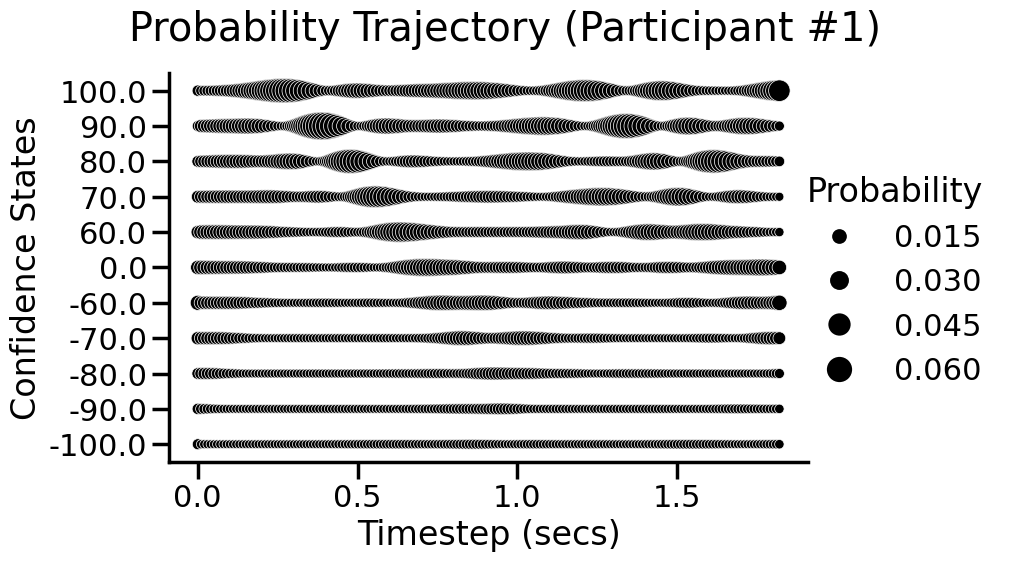

In [51]:
with sns.plotting_context(context="poster"):
    f = sns.relplot(df_quantum_plot.query("prior=='Uniform' and time < 18.24").assign(time = lambda df: df.time * 0.1), 
    x="time", y="states",size="value", legend=True, sizes=(40,400), aspect=1.5, color="black", height=5.5 )
    f.set(yticks = states_ticks)
    f.set_yticklabels(labels=states_labels)
    f.set_ylabels("Confidence States")
    f.set_xlabels("Timestep (secs)")
    f.legend.set_title("Probability")
    f.figure.suptitle("Probability Trajectory (Participant #1)", y=1.05)


In [ ]:
fig = px.scatter(df_quantum_plot.query("prior=='Uniform'"), x="time", y="states",size="value")
fig.update_layout( 
    scene=dict(aspectratio = dict( x=1, y=0.1 ),
    aspectmode = 'manual'),
    autosize=True)

f = sns.relplot(df_quantum_plot.astype({"states":"category"}),
x="time", y="states",size="value", col="prior", sizes=(40,400), color="Black", aspect=1, height = 4.5)
f.set_titles("{col_name}")
f.legend.set_title("Probability")
f.set_xlabels("Response Time (secs)")
f.set_ylabels("Confidence States")
#f.legend.set_loc("lower right")

In [ ]:
mv = np.arange(-(n_states//2), (n_states//2)+1)
mv

In [ ]:
start_width

In [ ]:
df_markov1 = pd.DataFrame()
df_quantum1 = pd.DataFrame()

for mu in [npx.asarray([[0.05]]), npx.asarray([[-0.05]]), npx.asarray([[1]]), npx.asarray([[-1]])]:
    intensity_matrix_markov = dd._buildK(n_states, mu, m_sigma)
    intensity_matrix_quantum = qd._buildH(n_states, mu, q_sigma)
    print(intensity_matrix_markov)
    for prior_type in ["Upper", "Uniform", "Lower"]:
        phi_0_markov = ca._get_initial_state(n_states, start_width,model_type="Markov", prior_type=prior_type)
        phi_0_quantum = ca._get_initial_state(n_states, start_width,model_type="Quantum" , prior_type=prior_type)
        
        phi_markov_arr = []
        phi_quantum_arr = []

        #phi_markov_arr.append(np.asarray(phi_0_markov.squeeze() @ mv))
        #phi_quantum_arr.append((np.abs(phi_0_quantum.squeeze())**2) @ mv)


        for t in np.arange(1,20,0.1):
            phi_markov = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_markov_arr.append(np.asarray(phi_markov.squeeze() @ mv))
        for t in np.arange(1,20,0.1):
            phi_quantum = ca.perform_state_transition(intensity_matrix_quantum, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                    q_Mc, q_Mw, q_Mn, phi_0_quantum, delta, 
                                                    transition_type="RT", likelihood_type="SINGLE")
            phi_quantum_arr.append((np.abs(phi_quantum.squeeze())**2) @ mv)
        
        df_markov1 = pd.concat([df_markov1, pd.DataFrame(phi_markov_arr).T.assign(prior=prior_type, mu=f"$v$={np.asarray(mu[0,0])}, $\sigma$={np.asarray(m_sigma[0,0])}")])
        df_quantum1 = pd.concat([df_quantum1, pd.DataFrame(phi_quantum_arr).T.assign(prior=prior_type, mu=f"$v$={np.asarray(mu[0,0])}, $\sigma$={np.asarray(m_sigma[0,0])}")])
        

In [ ]:
df_markov1_plot = df_markov1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1).assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_quantum1_plot = df_quantum1.melt(id_vars=["prior", "mu"], var_name="time").assign(time=lambda df: df.time*0.1).assign(prior = lambda df:df.prior.map({"Upper":"+High", "Lower":"-High", "Uniform":"Uniform"}))
df_markov1_plot.query("value > 3")

In [ ]:
df_markov1_plot

In [ ]:
f = sns.relplot(df_markov1_plot, x="time", y="value", 
                style="prior", col="mu", color="black", aspect=1, height=4, kind="line",lw=4)
f.legend.set_title("Initial Distr")
f.set_titles("{col_name}")
f.set_xlabels("RT (secs)")
f.set_ylabels("CS")


In [ ]:
f = sns.relplot(df_quantum1_plot, x="time", y="value", 
                style="prior", col="mu", color="black", aspect=1, height=4, kind="line",lw=4)
f.legend.set_title("Initial Distr")
f.set_titles("{col_name}")
f.set_xlabels("RT (secs)")
f.set_ylabels("CS")

In [ ]:
t = 7
t1 = 2
t2 = 1
t3 = t - (t1+t2)

P_markov_t = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t1 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t1]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t2 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t2]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t3 = ca.perform_state_transition(intensity_matrix_markov, npx.asarray([[t3]]), npx.asarray([[1]]), 
                                                m_Mc, m_Mw, m_Mn, phi_0_markov, delta, 
                                                transition_type="RT", likelihood_type="SINGLE")

P_markov_t.sum(), (m_Mc @ P_markov_t3).sum()  + (m_Mn_i @ P_markov_t2).sum() + (m_Mn_i @ P_markov_t1).sum()

In [ ]:
P_markov_t1.shape

In [ ]:
(m_Mn_i @ P_markov_t1).reshape(7,-1).shape

In [ ]:
P_markov_t.sum(), (m_Mn_i @ P_markov_t1).reshape(-1,7) @ np.eye(n_states) @ (m_Mc @ P_markov_t2).reshape(7,-1)

In [ ]:
(m_Mc @ P_markov_t2).sum()

In [ ]:
(m_Mn_i @ P_markov_t1).sum()

In [ ]:
P_markov_t.sum(), (m_Mc @ P_markov_t2).sum()  + (m_Mn_i @ P_markov_t1).sum()

In [ ]:
n=2
m_Mn_i = (npx.eye(n_states) - m_Mc)/n


In [ ]:
m_Mn_i